<a href="https://colab.research.google.com/github/u9828057/Python_Practice/blob/main/Electronics_with_Python/Electronics_Simulation_08_29_MOSFET_%E8%B2%A0%E8%BC%89%E7%B7%9A%E8%88%87%E5%81%8F%E5%A3%93%E9%BB%9E%E5%88%86%E6%9E%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
#=========================================
# --- Colab 畫圖中文顯示起手式 ---
#=========================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 下載微軟正黑體 (或是 Noto 繁體中文)
!wget -q -O NotoSansTC-Regular.otf \
https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf
fm.fontManager.addfont('NotoSansTC-Regular.otf')
plt.rc('font', family='Noto Sans CJK TC')
plt.rcParams['axes.unicode_minus'] = False
# --------------------------------

print("環境設定完成！可以開始畫圖了！")

環境設定完成！可以開始畫圖了！


--------(Electronics_Simulation: MOSFET 負載線與偏壓點分析)--------



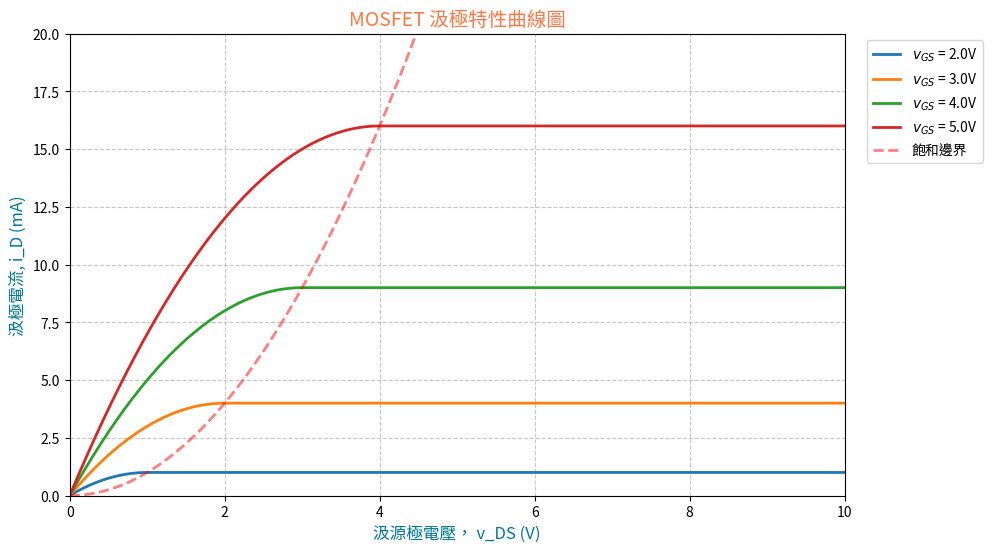


 MOSFET Q-point Analysis (v_GS = 4.0V)
 - V_DSQ = 5.500 V
 - I_DQ = 9.000 mA
 - Region = Saturation (飽和區)


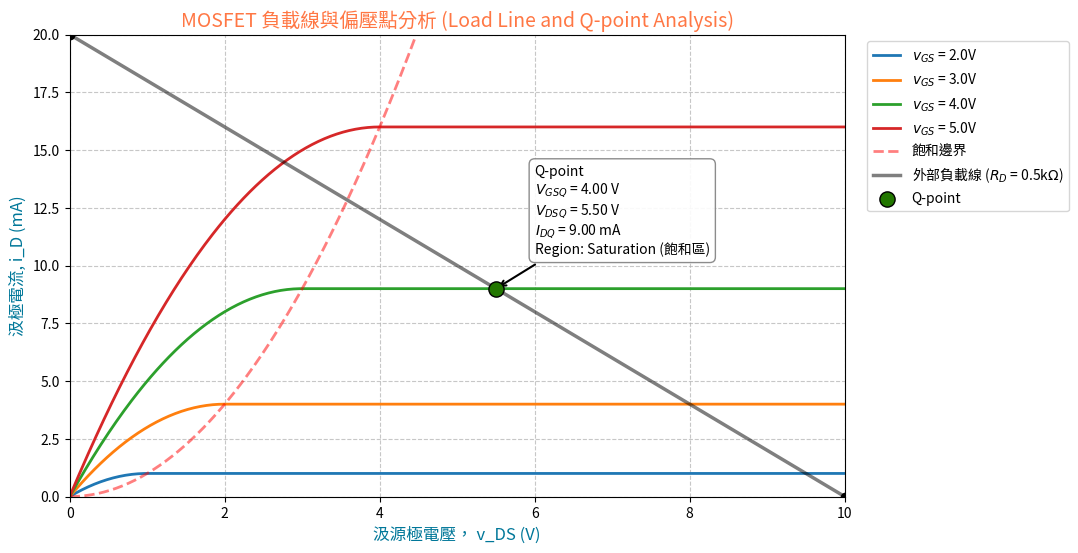


 MOSFET Q-point Analysis (v_GS = 5.0V)
 - V_DSQ = 2.764 V
 - I_DQ = 14.472 mA
 - Region = Triode (三極體區)


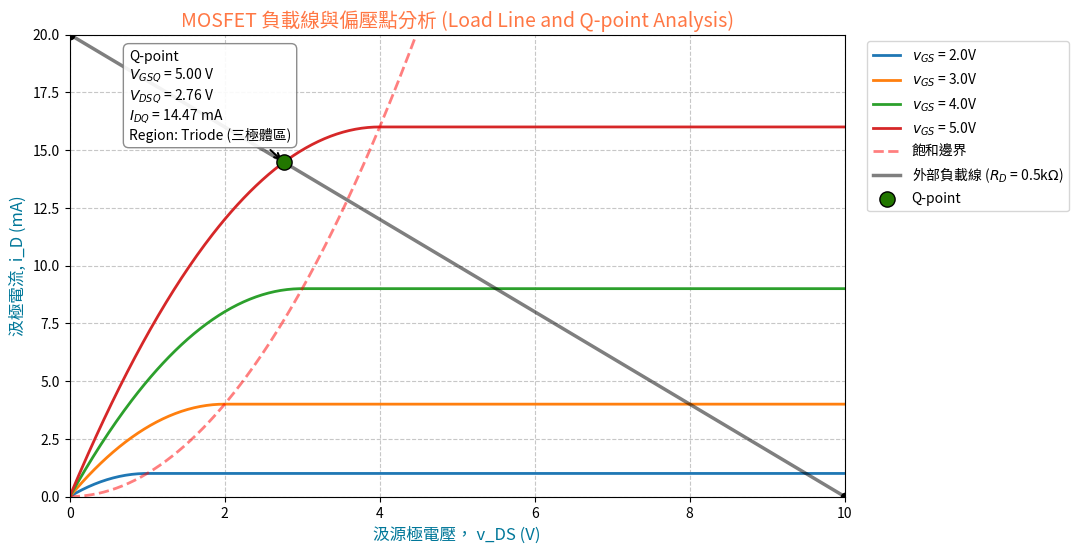

In [83]:
import numpy as np
import matplotlib.pyplot as plt
print("--------(Electronics_Simulation: MOSFET 負載線與偏壓點分析)--------\n")

#===========================================
# ◇ 主函式: MOSFET 繪圖與偏壓點分析
#===========================================

def plot_mosfet_analysis(show_loadline=False, v_GS_Q=4.0):

  # 1. 設定元件參數
  V_T = 1.0   # 臨界電壓 (Threshold Voltage) (V)
  K = 2e-3   # 導電參數 (A/V**2)
  V_DD = 10.0  # 汲極電壓 (V)
  R_D = 5e2   # 汲極電阻 (Ohm)

  # 2. 建立 X 軸電壓陣列
  v_DS = np.linspace(0, 10.0, 500)

  # 3. 建立畫布
  plt.figure(figsize=(10, 6))

  # 4. 使用 for 迴圈繪製特性曲線
  v_GS_list = [2.0, 3.0, 4.0, 5.0]

  for v_GS in v_GS_list:
    v_ov = v_GS - V_T   # v_ov (過驅電壓 Overdrive Voltage)
    i_D = np.where(
        v_ov <= v_DS,
        K*0.5*((v_ov)**2),
        K*((v_ov)*v_DS - 0.5*(v_DS**2))
        )

    plt.plot(v_DS, i_D*1000, label=f"$v_{{GS}}$ = {v_GS}V", linewidth=2)

  # 5. 繪製飽和邊界線
  i_D_boundary = K * 0.5 * (v_DS**2)

  plt.plot(v_DS, i_D_boundary*1000, "r--", label="飽和邊界",
      linewidth=2, alpha=0.5
      )


  #==============================================
  # ◇ 動態判斷: 是否疊加負載線與 Q-point
  #==============================================

  if show_loadline:

    # --- A. 繪製外部負載線 ---
    i_D_loadline = (V_DD - v_DS)/R_D * 1000

    plt.plot(v_DS, i_D_loadline, "k-",
        label=rf"外部負載線 ($R_D$ = {R_D/1000:.1f}k$\Omega$)",
        linewidth=2.5, alpha=0.5
        )

    plt.plot(V_DD, 0, "ko", markersize=6)        # X 截距
    plt.plot(0, (V_DD/R_D)*1000, "ko", markersize=6)   # Y 截距


    # --- B. 計算 Q-point 座標與工作區域 ---
    v_ov_Q = v_GS_Q - V_T

    if v_GS_Q <= V_T:
      region_Q = "Cutoff (截止區)"
      i_D_Q = 0.0
      v_DS_Q = V_DD
    else:
      # 先假設在飽和區
      i_D_sat_Q = K * 0.5 * (v_ov_Q**2)
      v_DS_sat_Q = V_DD - (i_D_sat_Q * R_D)

      # 檢查飽和區條件
      if v_DS_sat_Q >= v_ov_Q:
        region_Q = "Saturation (飽和區)"
        i_D_Q = i_D_sat_Q
        v_DS_Q = v_DS_sat_Q
      else:
        region_Q = "Triode (三極體區)"
        # 聯立一元二次方程式: a*(x**2) + b*x + c = 0
        a = 0.5 * K
        b = - (K*v_ov_Q + 1/R_D)
        c = (V_DD/R_D)
        roots = np.roots([a, b, c])

        # 取合理的實數解 (介於 0 與 v_ov 之間)
        valid_roots = [r.real for r in roots
                if np.isreal(r) and 0 <= r.real <= v_ov_Q
                ]
        v_DS_Q = valid_roots[0]
        i_D_Q = K*((v_ov_Q)*v_DS_Q - 0.5*(v_DS_Q**2))


    # --- C. 將 Q-point 標示在圖表上 ---
    i_D_Q_mA = i_D_Q * 1000
    plt.scatter(v_DS_Q, i_D_Q_mA, s=120, color="#227700",
          edgecolor="black", zorder=10, label="Q-point"
          )


    # 加入資訊方塊

    y_offset = 1.0 if i_D_Q_mA > 12 else 1.5
    #設定「動態調整註解框位置」的參數，如果電流大於 12 mA，就把文字框稍微降低，否則維持原狀
    x_offset = -2.0 if v_DS_Q < 4 else 0.5
    #設定「動態調整註解框位置」的參數，如果電壓小於 4 V，就會把文字框往左放，否則否則維持往右放

    plt.annotate(
        # 第一部分: 要顯示的文字內容
        (f"Q-point\n"
        f"$V_{{GSQ}}$ = {v_GS_Q:.2f} V\n"
        f"$V_{{DSQ}}$ = {v_DS_Q:.2f} V\n"
        f"$I_{{DQ}}$ = {i_D_Q_mA:.2f} mA\n"
        f"Region: {region_Q}"),

        # 第二部分: 箭頭要指的位置
        xy=(v_DS_Q, i_D_Q_mA),

        # 第三部分: 文字框要放在哪個位置
        xytext=(v_DS_Q + x_offset, i_D_Q_mA + y_offset),   #套用動態偏移量

        # 第四部份: 箭頭的樣貌
        arrowprops=dict(arrowstyle="->", linewidth=1.5),

        # 第五部分: 外框的樣貌與文字大小
        bbox=dict(boxstyle="round,pad=0.4",
              fc="white", ec="gray", alpha=0.9),
        fontsize=10
    )


    # 印出並確認資訊
    print(f"\n MOSFET Q-point Analysis (v_GS = {v_GS_Q}V)")
    print(f" - V_DSQ = {v_DS_Q:.3f} V")
    print(f" - I_DQ = {i_D_Q_mA:.3f} mA")
    print(f" - Region = {region_Q}")

    chart_title = "MOSFET 負載線與偏壓點分析 (Load Line and Q-point Analysis)"
    file_name = "§補充內容 4.3.3 - Python繪圖_MOSFET 負載線與偏壓點分析.png"
  else:
    chart_title = "MOSFET 汲極特性曲線圖"
    file_name = "§補充內容 4.2.2 - Python繪圖_MOSFET 汲極特性曲線圖.png"


  #======================
  # ◇ 設定圖表格式
  #======================

  plt.title(chart_title, fontsize=14, fontweight="bold", color="#FF7744")
  plt.xlabel("汲源極電壓， v_DS (V)", fontsize=12, color="#007799")
  plt.ylabel("汲極電流, i_D (mA)", fontsize=12, color="#007799")
  plt.grid(True, linestyle="--", alpha=0.7)

  # 將圖例移至右側外圍
  plt.legend(fontsize=10, loc="upper left", bbox_to_anchor=(1.02, 1))
  plt.xlim(0, 10)
  plt.ylim(0, 20)

  # 儲存與顯示圖片
  plt.savefig(file_name, dpi=300, bbox_inches="tight")
  plt.show()


#=================================
# ◇ 執行函式: 漸進產出圖片
#=================================

# 第一張圖片: 純元件特性 (不包含負載線)
plot_mosfet_analysis(show_loadline=False)

# 第二張圖片: 疊加負載線，並求出 v_GS = 4.0V 時的 Q-point
plot_mosfet_analysis(show_loadline=True, v_GS_Q=4.0)

# 第三張圖片: 測試 v_GS = 5.0V 時的 Q-point
plot_mosfet_analysis(show_loadline=True, v_GS_Q=5.0)


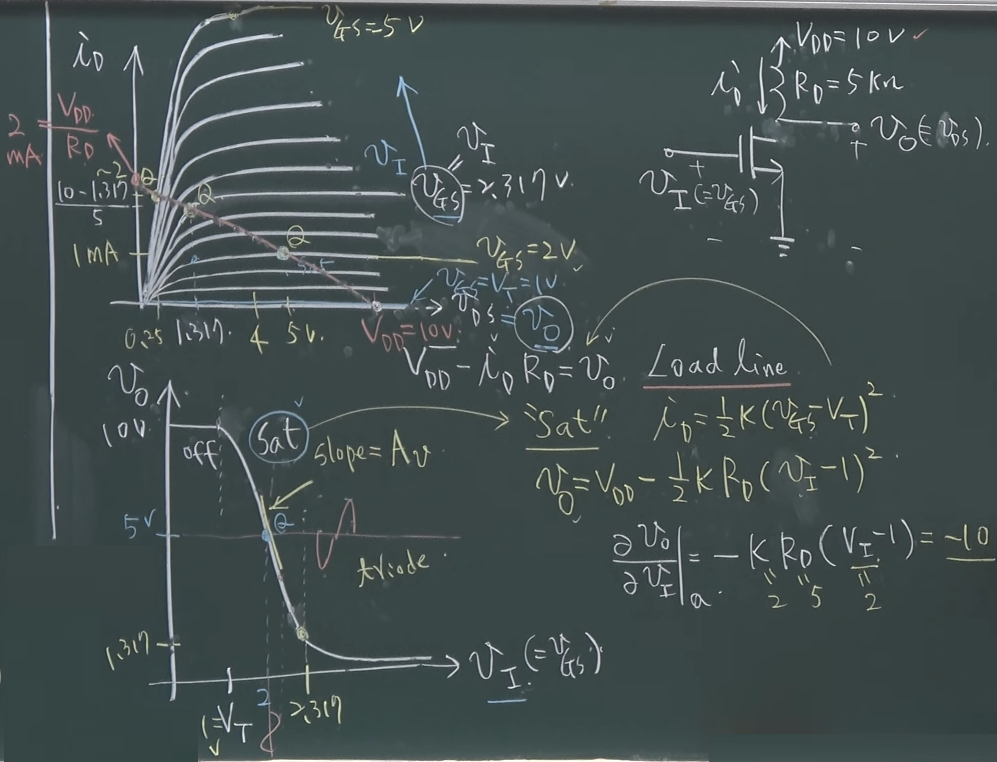

In [ ]:
#================================================================
# §理想 MOSFET 模型的汲極電流 i_D 在不同工作區的方程式
#================================================================

# 電晶體已經開啟 (v_GS > V_T):

# 歐姆區 (Deep Triode Region/Ohmic Region): 當 v_DS << v_GS -V_T 時
# i_D ≈ K*[(v_GS - V_T)v_DS]

# 三極管區 (Triode Region): 當 v_DS < v_GS - V_T 時
# i_D = K*[(v_GS - V_T)*v_DS - 0.5*(v_DS**2)]

# 飽和區 (Saturation Region): 當 v_DS >= v_GS - V_T 時
# i_D = K*0.5[(v_GS - V_T)**2]

#-------------------------------------------------------------

# 電晶體尚未開啟 (v_GS <= V_T):

# 截止區 (Cutoff Region): 當 v_GS <= V_T 時
# i_D = 0


#===========================
# 外部電路限制: 負載線
#===========================

# 在外部電路中，根據 KVL 電壓電源會分配給汲極電阻與 MOSFET 兩端: V_DD - (i_D * R_D) = v_DS
# 為了將這條線畫在以 "v_DS" 為 X 軸、"i_D" 為 Y 軸的圖表上，
# 可以將公式移項: i_D = -(1/R_D)*v_DS + V_DD/R_D

# 這是一條斜率為負值的直線，它的 X 軸截距發生在電流為 0 mA 時（也就是 V_DD），
# 而 Y 軸截距發生在電壓為 0V 時（也就是最大短路電流 V_DD / R_D）。


In [ ]:
#==========================================================
# ◇ np.roots([a, b, c]): 多項式方程式求解實用語法
#==========================================================
# [用途]: 自動解出代數方程式 (如一元二次方程式 ax**2 + bx + c = 0) 的所有根
# [場景]: 電子學分析中，當需要聯立「元件非線性曲線 (如三極體區)」 與 「直線方程式 (如負載線)」來求出 Q-point 交點時
#
# [參數解析]:
#    (1) 係數打包: 將方程式依照「最高次方到常數項」的順序，把係數抓取出來
#       以 ax**2 + bx + c = 0 為例，只需要輸入陣列 [a, b, c] 即可
#       roots = np.roots([a, b, c])
#
#    (2) 物理濾波 (Physical Constraints): 數學解有時不等於真實物理狀況
#       一元二次方程式一定會產生兩個根，但真實電路通常只有一個穩定狀態
#       因此必須透過「串列生成式 (List Comprehension)」加上條件判斷來過濾:
#
#       valid_roots = [
#         r.real                # 條件成立時，只取出該解的「實數部分」
#         for r in roots          # 迴圈取出 np.roots() 算出來的每一個解
#         if np.isreal(r)           # 條件一: 必須是實數 (電路中不存在虛數電壓)
#         and 0 <= r.real < v_ov     # 條件二: 必須符合三極體區的物理邊界限制
#       ]
#
#
# [結論]: 這是一套工程演算 SOP，先交給電腦解出所有數學根，再利用嚴謹的 if 條件式，根據邊界條件濾出唯一具有物理意義的解答


#==========================================================
# ◇ 數學聯立推導: 找出三極體區的精準交點 (Q-point)
#==========================================================
# [用途]: 將「MOSFET 內部物理限制」與「外部電路限制」結合成一元二次方程式，讓電腦自動計算出交點的 X 軸座標 (v_DS)
#
# [物理推導]: 交點代表電流 (i_D) 與電壓 (v_DS) 同時滿足元件的兩個方程式
#
#   (1) MOSFET 在三極體區的電流方程式 (內部物理限制):
#      i_D = K * [v_ov* v_DS - 0.5* (v_DS**2)]
#
#   (2) 外部 KVL 負載線的電流方程式 (外部電路限制):
#      i_D = (V_DD - v_DS) / R_D
#
#   (3) 將兩個方程式聯立 (等號右邊相等)，目標是解出未知數 v_DS:
#      K * v_ov * v_DS - 0.5 * K * (v_DS**2) = -(1/R_D)*v_DS + (V_DD/R_D)
#
#   (4) 移項整理成標準的一元二次方程式形式: a*(x**2) + b*x + c = 0
#      0.5*K*(v_DS**2) - (K*v_ov + 1/R_D)*v_DS + (V_DD/R_D) = 0
#
# [程式變數對應]:
#   對應到程式碼中的 a, b, c，這裡的 x 就是聯立推導要求的 v_DS_Q
#     a = 0.5 * K
#     b = - (K*v_ov + 1/R_D)
#     c = (V_DD/R_D)
